PHASE 1: DATA LOADING & PREPARATION

In [60]:
# ============================================
# IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import os
from functools import reduce

import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
# ============================================
# LOAD DATASET 1
# ============================================
data = pd.read_csv("GSE127696_Raw_counts.txt", sep="\t")

# set gene as index
data = data.set_index("gene_id")

# transpose → samples as rows
X1 = data.T

print("Dataset 1 shape:", X1.shape)

Dataset 1 shape: (78, 19165)


In [62]:
# ============================================
# LABELS FOR DATASET 1
# ============================================
y1 = ["CF" if str(idx).startswith("CF") else "NCF" for idx in X1.index]
y1 = np.array([0 if x == "CF" else 1 for x in y1])

In [63]:
# ============================================
# CLEAN + NORMALIZE
# ============================================
X1 = X1.apply(pd.to_numeric, errors="coerce")
X1 = X1.fillna(0)

# remove low expression genes
X1 = X1.loc[:, (X1 > 1).sum(axis=0) >= 5]

# log transform
X1 = np.log2(X1 + 1)

print("Dataset 1 cleaned shape:", X1.shape)

Dataset 1 cleaned shape: (78, 16336)


In [64]:
# ============================================
# LOAD RAW HTSEQ FILES
# ============================================
folder = "/content/htseq_files"

files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".gz")]

print("Total files:", len(files))

Total files: 49


In [65]:
# ============================================
# LOAD EACH FILE
# ============================================
def load_htseq(file):
    df = pd.read_csv(file, sep="\t", header=None)
    df.columns = ["gene", os.path.basename(file)]

    # remove unwanted rows
    df = df[~df["gene"].str.startswith("__")]

    return df

In [66]:
# ============================================
# MERGE FILES
# ============================================
dfs = [load_htseq(f) for f in files]

data_merged = reduce(
    lambda left, right: pd.merge(left, right, on="gene"),
    dfs
)

data_merged = data_merged.set_index("gene")

print("Merged Dataset shape:", data_merged.shape)

Merged Dataset shape: (60492, 49)


In [67]:
# ============================================
# TRANSPOSE DATASET 2
# ============================================
X2 = data_merged.T

print("Dataset 2 shape:", X2.shape)

Dataset 2 shape: (49, 60492)


In [68]:
# ============================================
# NORMALIZE DATASET 2
# ============================================
X2 = X2.apply(pd.to_numeric, errors="coerce")
X2 = X2.fillna(0)

# filter low expression genes
X2 = X2.loc[:, (X2 > 1).sum(axis=0) >= 5]

# log transform
X2 = np.log2(X2 + 1)

In [69]:
# ============================================
# LABELS FOR DATASET 2
# ============================================
y2 = []

for name in X2.index:
    if "CF" in name:
        y2.append(0)
    else:
        y2.append(1)

y2 = np.array(y2)

PHASE 2: GENE ALIGNMENT + DGE

In [70]:
# ============================================
# FIX GENE IDs (REMOVE VERSION NUMBERS)
# ============================================
X1.columns = X1.columns.str.split(".").str[0]
X2.columns = X2.columns.str.split(".").str[0]

In [71]:
X1.columns = X1.columns.str.upper()
X2.columns = X2.columns.str.upper()

In [72]:
print("X1 example genes:", list(X1.columns[:5]))
print("X2 example genes:", list(X2.columns[:5]))

X1 example genes: ['ENSG00000279928', 'ENSG00000187634', 'ENSG00000187961', 'ENSG00000187583', 'ENSG00000187608']
X2 example genes: ['5S_RRNA_2', '5S_RRNA_3', '7SK', 'A1BG', 'A1BG-AS1']


In [17]:
# ============================================
# INSTALL (run once)
# ============================================
!pip install mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00


In [73]:
# ============================================
# MAP ENSG → GENE SYMBOL
# ============================================
import mygene

mg = mygene.MyGeneInfo()

genes = list(X1.columns)

mapping = mg.querymany(
    genes,
    scopes='ensembl.gene',
    fields='symbol',
    species='human'
)

mapping_df = pd.DataFrame(mapping)

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-16336 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


In [74]:
# ============================================
# CLEAN MAPPING
# ============================================
mapping_df = mapping_df.dropna(subset=["symbol"])

mapping_dict = dict(zip(mapping_df["query"], mapping_df["symbol"]))

In [75]:
# ============================================
# RENAME COLUMNS
# ============================================
X1 = X1.rename(columns=mapping_dict)

# remove genes that didn't map
X1 = X1.loc[:, X1.columns.notna()]

# remove duplicates
X1 = X1.loc[:, ~X1.columns.duplicated()]

In [76]:
# ============================================
# FIND COMMON GENES
# ============================================
common_genes = list(set(X1.columns) & set(X2.columns))

print("Common genes:", len(common_genes))

Common genes: 13904


In [77]:
# ============================================
# ALIGN DATASETS
# ============================================
X1_common = X1[common_genes]
X2_common = X2[common_genes]

print("Dataset 1 aligned:", X1_common.shape)
print("Dataset 2 aligned:", X2_common.shape)

Dataset 1 aligned: (78, 13904)
Dataset 2 aligned: (49, 13904)


In [78]:
# ============================================
# SPLIT GROUPS
# ============================================
cf_samples = X1_common[y1 == 0]
ncf_samples = X1_common[y1 == 1]

print("CF samples:", cf_samples.shape)
print("Healthy samples:", ncf_samples.shape)

CF samples: (42, 13904)
Healthy samples: (36, 13904)


In [79]:
from scipy.stats import ttest_ind, mannwhitneyu

t_pvalues = []
mw_pvalues = []
fold_changes = []

genes = X1_common.columns

for gene in genes:

    cf_vals = cf_samples[gene]
    ncf_vals = ncf_samples[gene]

    # t-test
    t_stat, t_p = ttest_ind(cf_vals, ncf_vals, equal_var=False)

    # Mann-Whitney
    mw_stat, mw_p = mannwhitneyu(cf_vals, ncf_vals)

    # Fold Change
    fc = np.log2(cf_vals.mean() + 1) - np.log2(ncf_vals.mean() + 1)

    t_pvalues.append(t_p)
    mw_pvalues.append(mw_p)
    fold_changes.append(fc)

In [80]:
# ============================================
# CREATE DGE DATAFRAME
# ============================================
dge_df = pd.DataFrame({
    "gene": genes,
    "t_pvalue": t_pvalues,
    "mw_pvalue": mw_pvalues,
    "log2FC": fold_changes
})

In [81]:
from statsmodels.stats.multitest import multipletests

dge_df["adj_pvalue"] = multipletests(dge_df["t_pvalue"], method="fdr_bh")[1]

dge_df = dge_df.sort_values("adj_pvalue")

In [82]:
top_dge_genes = dge_df.head(50)["gene"].values

print("Top DGE genes:", top_dge_genes[:10])

Top DGE genes: ['SLC22A16' 'DPP10' 'ZFHX4' 'ACOX2' 'FAM107A' 'MKRN3' 'CD200R1' 'SAMD3'
 'UBASH3B' 'TMEM200A']


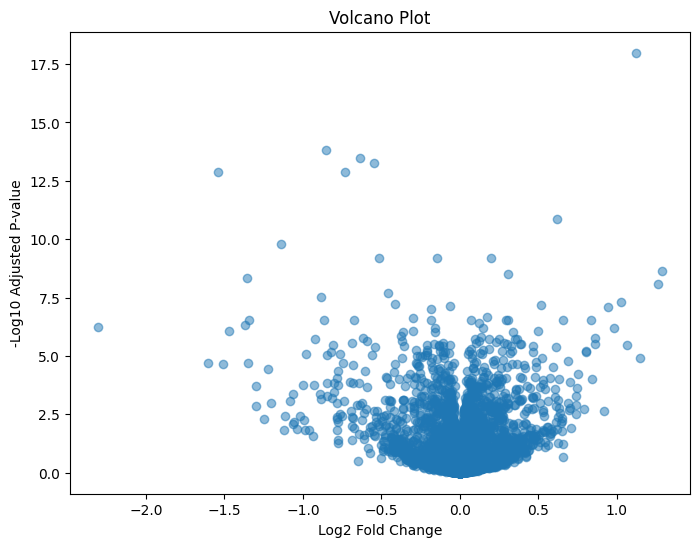

In [83]:
# ============================================
# VOLCANO PLOT
# ============================================
plt.figure(figsize=(8,6))

plt.scatter(
    dge_df["log2FC"],
    -np.log10(dge_df["adj_pvalue"]),
    alpha=0.5
)

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Volcano Plot")

plt.show()

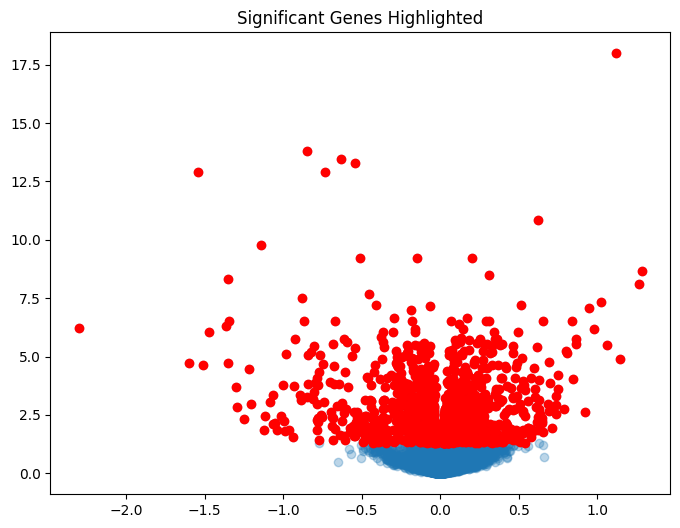

In [84]:
# highlight significant genes
sig = dge_df[dge_df["adj_pvalue"] < 0.05]

plt.figure(figsize=(8,6))

plt.scatter(
    dge_df["log2FC"],
    -np.log10(dge_df["adj_pvalue"]),
    alpha=0.3
)

plt.scatter(
    sig["log2FC"],
    -np.log10(sig["adj_pvalue"]),
    color="red"
)

plt.title("Significant Genes Highlighted")
plt.show()

PHASE 3: FEATURE SELECTION + SCALING + PCA + MODEL PREP

In [85]:
# ============================================
# TRAIN-TEST SPLIT
# ============================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X1_common,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (62, 13904)
Test shape: (16, 13904)


In [86]:
# ============================================
# FEATURE SELECTION
# ============================================
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=500)

X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

selected_genes = X_train.columns[selector.get_support()]

print("Selected features:", len(selected_genes))

Selected features: 500


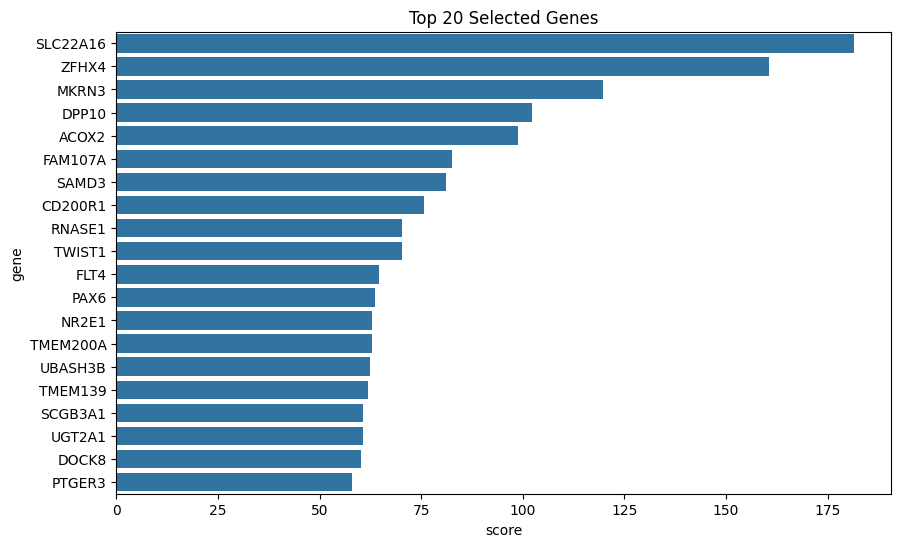

In [87]:
# ============================================
# FEATURE SCORE VISUALIZATION
# ============================================
scores = selector.scores_

feature_scores = pd.DataFrame({
    "gene": X_train.columns,
    "score": scores
})

top_features = feature_scores.sort_values("score", ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x="score", y="gene", data=top_features)
plt.title("Top 20 Selected Genes")
plt.show()

In [88]:
# ============================================
# STANDARD SCALING
# ============================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

In [89]:
# ============================================
# TRAIN MODEL ON SELECTED FEATURES (NO PCA)
# ============================================
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)

rf_fs.fit(X_train_sel, y_train)

importances = rf_fs.feature_importances_

selected_gene_list = X_train.columns[selector.get_support()]

In [90]:
# ============================================
# PCA
# ============================================
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Reduced shape:", X_train_pca.shape)

Reduced shape: (62, 50)


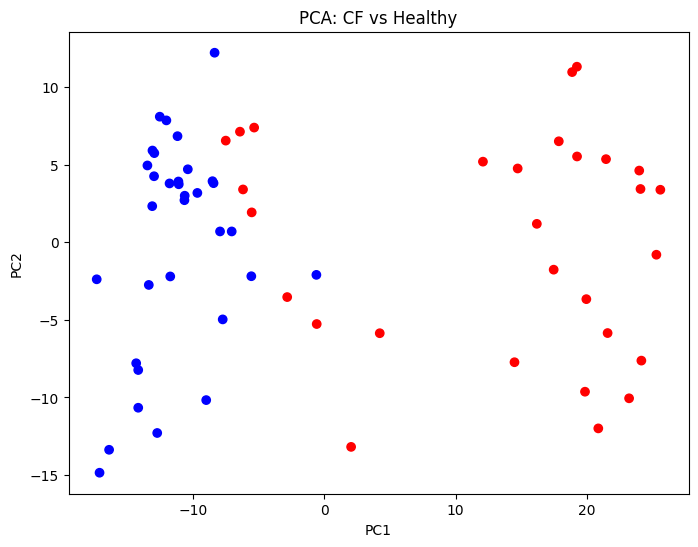

In [91]:
# ============================================
# PCA VISUALIZATION
# ============================================
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))

colors = ['blue' if label == 0 else 'red' for label in y_train]

plt.scatter(X_vis[:,0], X_vis[:,1], c=colors)

plt.title("PCA: CF vs Healthy")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

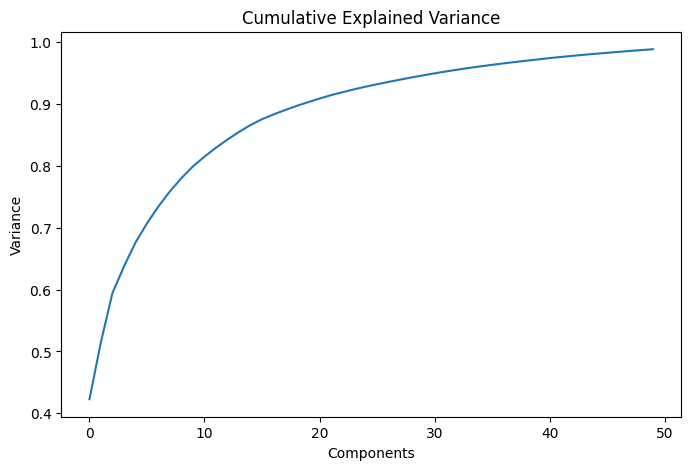

In [92]:
# ============================================
# PCA VARIANCE
# ============================================
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("Cumulative Explained Variance")
plt.xlabel("Components")
plt.ylabel("Variance")
plt.show()

In [93]:
# ============================================
# APPLY SAME PIPELINE TO DATASET 2
# ============================================

# align already done → X2_common

X2_sel = selector.transform(X2_common)
X2_scaled = scaler.transform(X2_sel)
X2_pca = pca.transform(X2_scaled)

PHASE 4: MODEL + VALIDATION + GENERALIZATION

In [94]:
# ============================================
# MODEL TRAINING
# ============================================
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_pca, y_train)

RandomForestClassifier(random_state=42)

In [95]:
# ============================================
# TEST EVALUATION
# ============================================
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_pca)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9375
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.86      0.92         7

    accuracy                           0.94        16
   macro avg       0.95      0.93      0.94        16
weighted avg       0.94      0.94      0.94        16



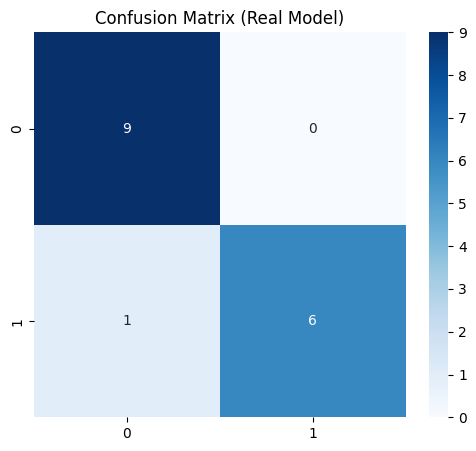

In [96]:
# ============================================
# CONFUSION MATRIX
# ============================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Real Model)")
plt.show()

In [97]:
# ============================================
# STRATIFIED CV
# ============================================
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X_train_pca, y_train, cv=skf)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Scores: [0.92307692 1.         1.         0.83333333 1.        ]
Mean CV Accuracy: 0.9512820512820515


In [98]:
# ============================================
# SHUFFLE TEST
# ============================================
y_shuffled = np.random.permutation(y_train)

model.fit(X_train_pca, y_shuffled)

y_pred_fake = model.predict(X_test_pca)

print("Shuffled Accuracy:",
      accuracy_score(y_test, y_pred_fake))

print(classification_report(y_test, y_pred_fake))

Shuffled Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.56      0.56      0.56         9
           1       0.43      0.43      0.43         7

    accuracy                           0.50        16
   macro avg       0.49      0.49      0.49        16
weighted avg       0.50      0.50      0.50        16



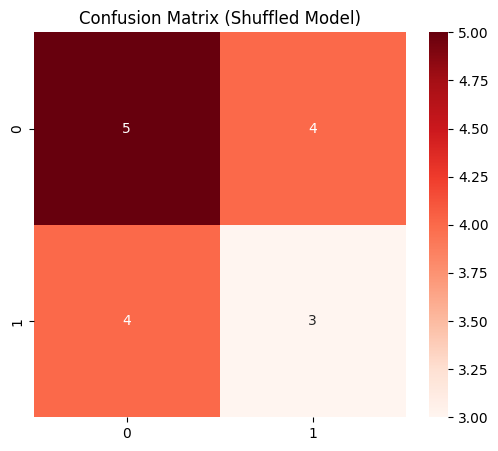

In [99]:
cm_fake = confusion_matrix(y_test, y_pred_fake)

plt.figure(figsize=(6,5))
sns.heatmap(cm_fake, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix (Shuffled Model)")
plt.show()

In [100]:
# ============================================
# RESTORE MODEL
# ============================================
model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)

In [101]:
# ============================================
# CROSS-DATASET PREDICTIONS (UNLABELED DATA)
# ============================================
y_pred_2 = model.predict(X2_pca)

# distribution of predictions
unique, counts = np.unique(y_pred_2, return_counts=True)

print("Predicted class distribution:")
print(dict(zip(unique, counts)))

Predicted class distribution:
{np.int64(1): np.int64(49)}


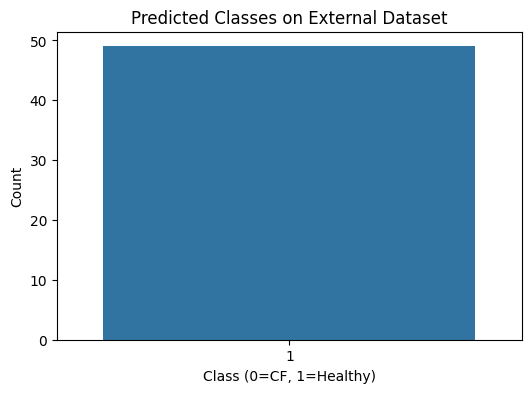

In [102]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_pred_2)
plt.title("Predicted Classes on External Dataset")
plt.xlabel("Class (0=CF, 1=Healthy)")
plt.ylabel("Count")
plt.show()

In [103]:
print("Train label distribution:", np.bincount(y_train))

Train label distribution: [33 29]


In [104]:
probs = model.predict_proba(X2_pca)

confidence = np.mean(np.max(probs, axis=1))
print("Average prediction confidence:", confidence)

Average prediction confidence: 0.556530612244898


PHASE 5: BIOMARKERS + CF ACTIVITY + FINAL INSIGHTS

In [108]:
# ============================================
# FEATURE IMPORTANCE (FIXED)
# ============================================

rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_train_sel, y_train)

importances = rf_fs.feature_importances_

# FIXED LINE
selected_gene_list = X_train.columns[selector.get_support()]

# sanity check
print(len(importances))
print(len(selected_gene_list))

importance_df = pd.DataFrame({
    "gene": selected_gene_list,
    "importance": importances
})

top_genes_df = importance_df.sort_values("importance", ascending=False)

top_genes = top_genes_df.head(20)

print(top_genes)

500
500
         gene  importance
256     ZFHX4    0.094207
494  SLC22A16    0.084709
225     ACOX2    0.037962
103     ARL11    0.030107
427     SAMD3    0.028286
1      PTGER4    0.024689
290     DPP10    0.022187
115     MKRN3    0.021661
221     PADI2    0.018001
20       PEG3    0.017109
62       LY96    0.016738
437      FBN2    0.015600
474    RNASE1    0.014039
117   FAM107A    0.013328
309   CD200R1    0.012472
243    ZNF727    0.011598
39    SCGB3A1    0.011497
143     OR2A7    0.010331
54     SAMD13    0.010093
240   TMEM139    0.010054


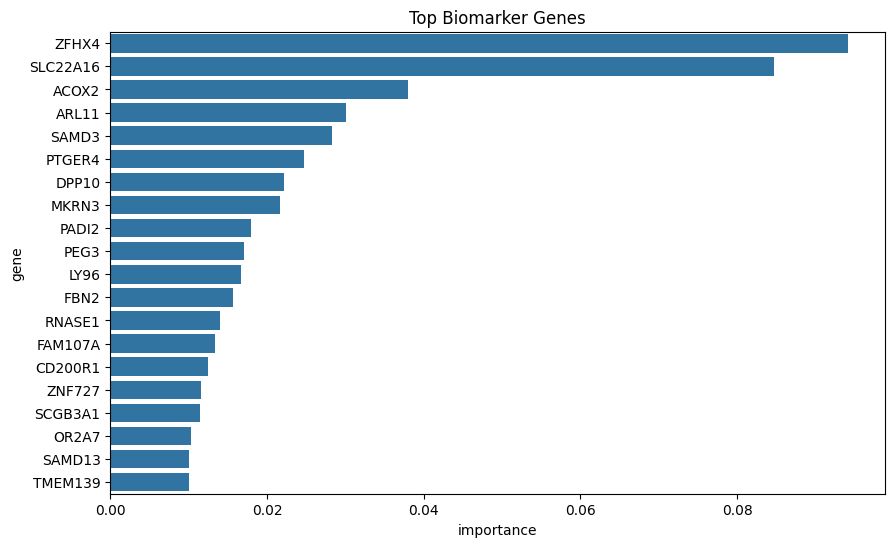

In [109]:
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="gene", data=top_genes)
plt.title("Top Biomarker Genes")
plt.show()

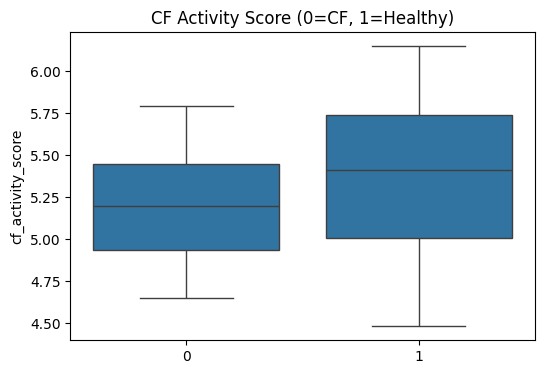

In [110]:
# ============================================
# CF ACTIVITY SCORE
# ============================================
top_gene_names = list(top_genes["gene"])

X_train_df = pd.DataFrame(X_train, columns=X1_common.columns)

X_train_df["cf_activity_score"] = X_train_df[top_gene_names].mean(axis=1)

# plot
plt.figure(figsize=(6,4))
sns.boxplot(x=y_train, y=X_train_df["cf_activity_score"])
plt.title("CF Activity Score (0=CF, 1=Healthy)")
plt.show()

In [111]:
from scipy.stats import pearsonr

correlations = []

for gene in top_gene_names:
    corr, _ = pearsonr(
        X_train_df[gene],
        X_train_df["cf_activity_score"]
    )
    correlations.append((gene, corr))

corr_df = pd.DataFrame(correlations, columns=["gene", "correlation"])

print(corr_df.sort_values("correlation", ascending=False))

        gene  correlation
15    ZNF727     0.681001
9       PEG3     0.584687
13   FAM107A     0.495197
3      ARL11     0.450695
2      ACOX2     0.362879
18    SAMD13     0.344898
6      DPP10     0.337097
0      ZFHX4     0.310029
7      MKRN3     0.276622
4      SAMD3     0.235117
8      PADI2     0.226684
16   SCGB3A1     0.157848
19   TMEM139     0.154696
10      LY96     0.149093
17     OR2A7     0.106353
12    RNASE1     0.046840
14   CD200R1     0.041168
5     PTGER4    -0.057886
1   SLC22A16    -0.089693
11      FBN2    -0.151362


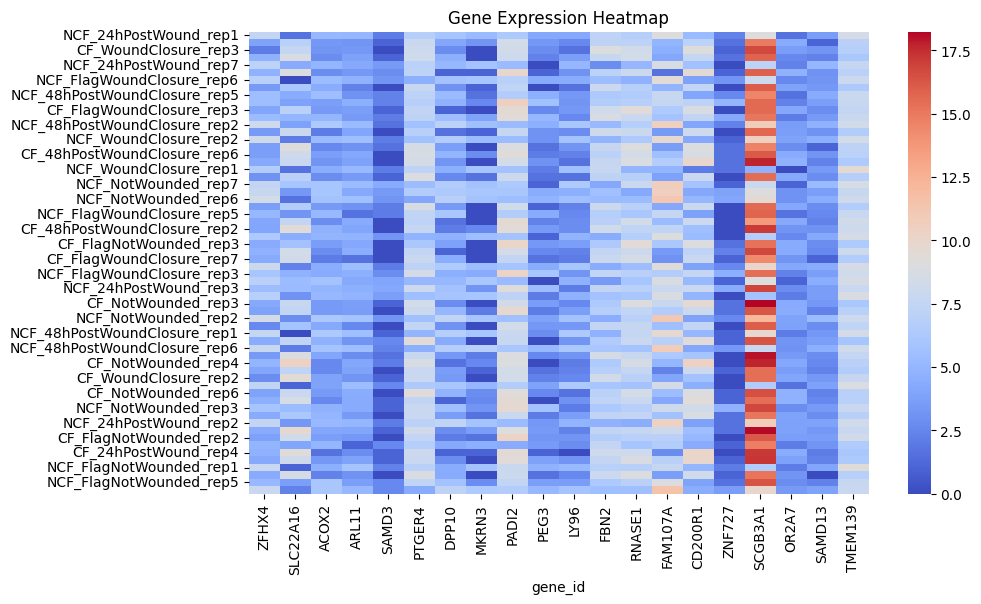

In [112]:
# ============================================
# HEATMAP OF TOP GENES
# ============================================
plt.figure(figsize=(10,6))

sns.heatmap(
    X_train_df[top_gene_names],
    cmap="coolwarm"
)

plt.title("Gene Expression Heatmap")
plt.show()

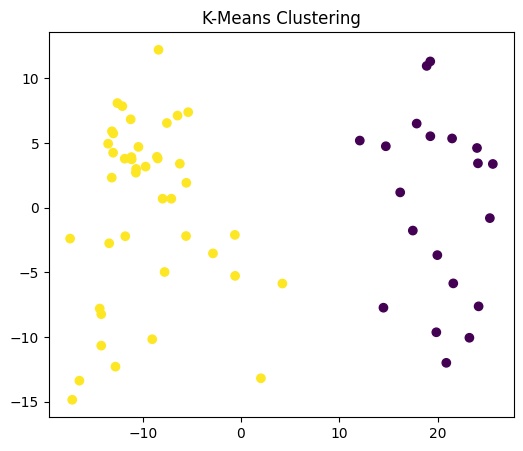

In [113]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X_train_pca)

plt.figure(figsize=(6,5))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=clusters)
plt.title("K-Means Clustering")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


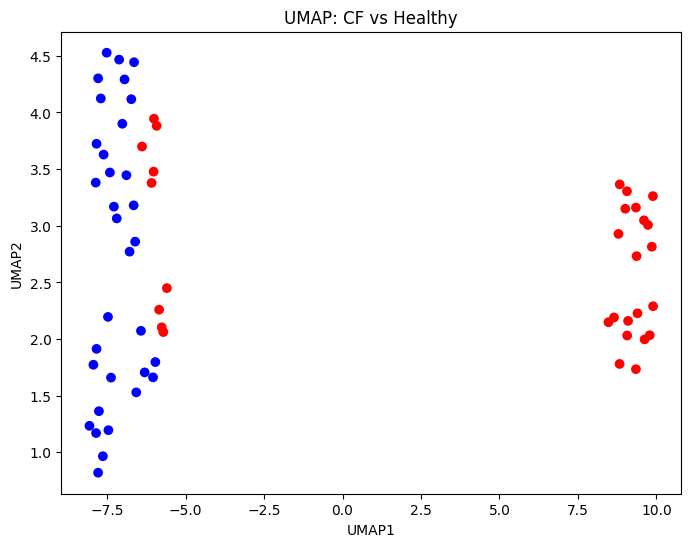

In [114]:
# ============================================
# UMAP VISUALIZATION
# ============================================
!pip install umap-learn

import umap.umap_ as umap

umap_model = umap.UMAP(n_components=2, random_state=42)

X_umap = umap_model.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))

colors = ['blue' if label == 0 else 'red' for label in y_train]

plt.scatter(X_umap[:,0], X_umap[:,1], c=colors)

plt.title("UMAP: CF vs Healthy")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.show()

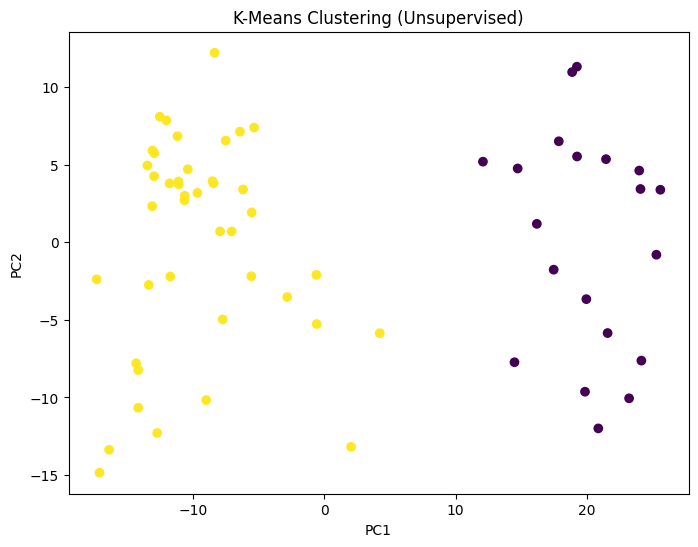

In [115]:
# ============================================
# K-MEANS CLUSTERING
# ============================================
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X_train_pca)

plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=clusters
)

plt.title("K-Means Clustering (Unsupervised)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

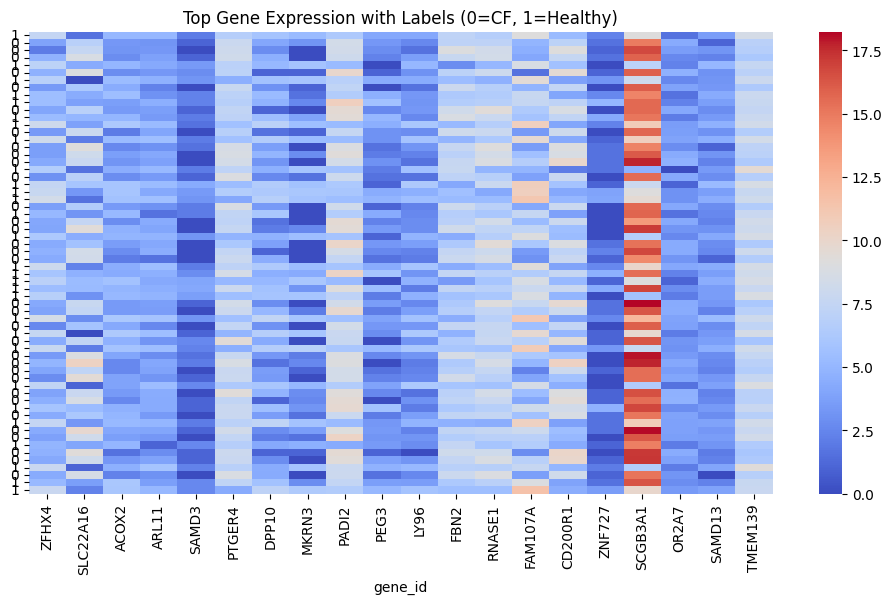

In [116]:
# ============================================
# LABELED HEATMAP
# ============================================
plt.figure(figsize=(12,6))

sns.heatmap(
    X_train_df[top_gene_names],
    cmap="coolwarm",
    yticklabels=y_train
)

plt.title("Top Gene Expression with Labels (0=CF, 1=Healthy)")
plt.show()

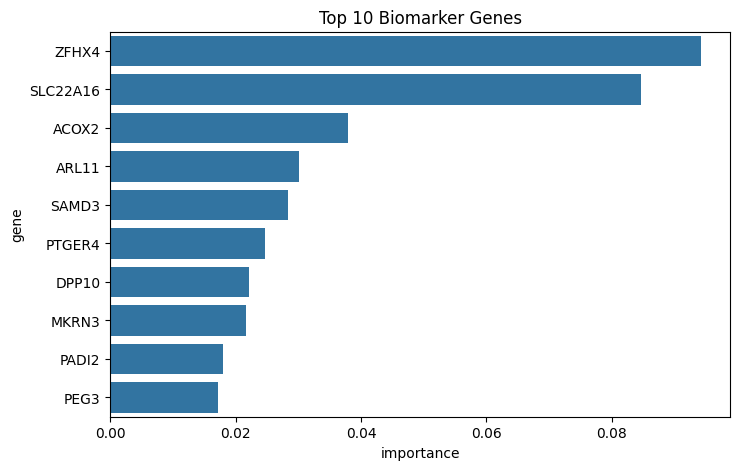

In [117]:
# ============================================
# CLEAN FEATURE IMPORTANCE
# ============================================
top10 = top_genes.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x="importance",
    y="gene",
    data=top10
)

plt.title("Top 10 Biomarker Genes")
plt.show()

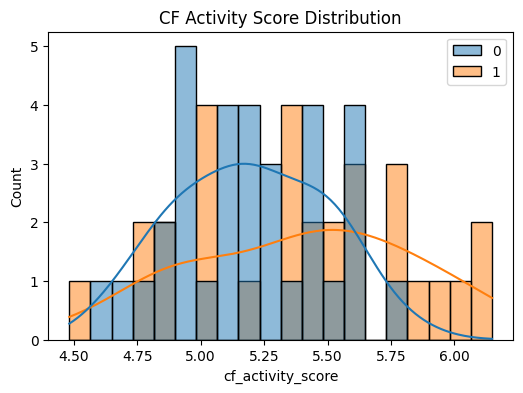

In [118]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=X_train_df,
    x="cf_activity_score",
    hue=y_train,
    bins=20,
    kde=True
)

plt.title("CF Activity Score Distribution")
plt.show()